In [1]:
# AB TEST 

In [2]:
import numpy as np
import pandas as pd

In [3]:
np.random.seed(42)

In [4]:
N = 80000

In [5]:
df = pd.DataFrame({
    'user_id': range(N),
    'tenure_months': np.random.exponential(24,N).clip(0,120),
    'prior_engagement':np.random.beta(2,23,N),
    'account_type': np.random.choice(['basic', 'premium'], N, p=[0.75,0.25])
})

In [6]:
df.head()

,user_id,tenure_months,prior_engagement,account_type
0,0,11.262434,0.050438,premium
1,1,72.242914,0.053145,premium
2,2,31.601897,0.081376,basic
3,3,21.910621,0.088490,basic
4,4,4.070997,0.075453,basic


In [7]:
df['arm'] = np.random.choice(['control', 'treatment'], N, p=[0.502,0.498])

In [8]:
df.head(20)

,user_id,tenure_months,prior_engagement,account_type,arm
0,0,11.262434,0.050438,premium,treatment
1,1,72.242914,0.053145,premium,control
2,2,31.601897,0.081376,basic,treatment
3,3,21.910621,0.088490,basic,treatment
4,4,4.070997,0.075453,basic,treatment
5,5,4.070311,0.043916,basic,treatment
6,6,1.436130,0.023327,premium,control
7,7,48.269541,0.053019,basic,treatment
8,8,22.057972,0.072430,basic,control
9,9,29.550001,0.098126,basic,control


In [9]:
def sigmoid(x): return 1/(1+np.exp(-x))

In [10]:
base_logit = (
    -2.45
    + 1.5 * (df['prior_engagement'] - df['prior_engagement'].mean())
    + 0.05 * (df['tenure_months'] / 24)
)

In [11]:
true_effect_logit = 0.22

In [12]:
treatment = (df['arm'] == 'treatment').astype(int)

In [13]:
df['clicked'] = np.random.binomial(1, sigmoid(base_logit + true_effect_logit * treatment))

In [14]:
df['time-to-click'] = np.where(df['clicked'], np.random.exponential(45,N), np.nan)

In [15]:
df['confirmed_fraud'] = df['clicked'] * np.random.binomial(1,0.35,N)

In [16]:
df['unsubscribed'] = np.random.binomial(1,0.0025 + 0.0002 * treatment, N)

In [17]:
df['support ticket'] = np.random.binomial(1,0.012, N)

In [18]:
df['confirmed_fraud'].value_counts()

confirmed_fraud
0    77369
1     2631
Name: count, dtype: int64

In [19]:
df['unsubscribed'].value_counts()

unsubscribed
0    79791
1      209
Name: count, dtype: int64

In [20]:
df.head()

,user_id,tenure_months,prior_engagement,account_type,arm,clicked,time-to-click,confirmed_fraud,unsubscribed,support ticket
0,0,11.262434,0.050438,premium,treatment,0,NaN,0,0,0
1,1,72.242914,0.053145,premium,control,0,NaN,0,0,0
2,2,31.601897,0.081376,basic,treatment,0,NaN,0,0,0
3,3,21.910621,0.088490,basic,treatment,0,NaN,0,0,0
4,4,4.070997,0.075453,basic,treatment,0,NaN,0,0,0


In [21]:
df['support ticket'].value_counts()

support ticket
0    79014
1      986
Name: count, dtype: int64

In [22]:
df.groupby('arm')['clicked'].mean()

arm
control      0.084721
treatment    0.101775
Name: clicked, dtype: float64

In [23]:
df.groupby('arm').agg(
    n=('clicked', 'count'),
    clicks=('clicked', 'sum'),
    ctr=('clicked', 'mean')
)

,n,clicks,ctr
arm,,,
control,40285,3413,0.084721
treatment,39715,4042,0.101775


In [24]:
from scipy.stats import chisquare

In [25]:
counts = df['arm'].value_counts()
chi2, p = chisquare(counts)
print(counts, '\np-value', p)

arm
control      40285
treatment    39715
Name: count, dtype: int64 
p-value 0.04387800789041376


In [26]:
n_c = (df['arm'] == 'control').sum()
n_t = (df['arm'] == 'treatment').sum()

clicks_c = df.loc[df['arm'] == 'control', 'clicked'].sum()
clicks_t = df.loc[df['arm'] == 'treatment', 'clicked'].sum()

p_c = clicks_c / n_c
p_t = clicks_t / n_t

print(n_c, n_t, clicks_c, clicks_t, p_c, p_t)

40285 39715 3413 4042 0.08472136030780687 0.10177514792899409


In [27]:
diff = p_t - p_c

In [28]:
diff

np.float64(0.017053787621187214)

In [29]:
p_pool = (clicks_c + clicks_t) / (n_c + n_t)

In [30]:
import numpy as np

In [31]:
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))

In [32]:
z = diff / se
print(z)

8.296353424695312


In [33]:
from scipy.stats import norm

In [34]:
p_value = 2 * (1-norm.cdf(abs(z)))

In [35]:
p_value

np.float64(0.0)

In [36]:
se_ci = np.sqrt(p_c * (1-p_c) / n_c + p_t * (1-p_t) / n_t)

In [37]:
ci_low = diff - 1.96 * se_ci
ci_high = diff + 1.96 * se_ci
print(ci_low, ci_high)

0.013024234865670791 0.021083340376703636


In [38]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

In [39]:
count = [clicks_t, clicks_c]
nobs = [n_t, n_c]

z_stat, p_val = proportions_ztest(count, nobs, alternative='two-sided')
print(f"z = {z_stat:.3f}, p = {p_val:2e}")

ci_low, ci_high = confint_proportions_2indep(clicks_t, n_t, clicks_c, n_c, method='wald')

print(f"95% CI for lift: [{ci_low:.4f}, {ci_high:.4f}]")

z = 8.296, p = 1.073558e-16
95% CI for lift: [0.0130, 0.0211]


## Confirmed Fraud

In [40]:
control = df['arm'] == 'control'
treatment = df['arm'] == 'treatment'
n_c,n_t = int(control.sum()), int(treatment.sum())

In [41]:
cf_c = df.loc[control, 'confirmed_fraud'].sum()
cf_t = df.loc[treatment, 'confirmed_fraud'].sum()

In [42]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

In [43]:
z, p = proportions_ztest([cf_t, cf_c], [n_t, n_c])
ci_l, ci_h = confint_proportions_2indep(cf_t, n_t, cf_c, n_c, method='wald')

In [44]:
print(f"Control fraud rate: {cf_c / n_c:.4f}")
print(f"Treatment fraud rate: {cf_t / n_t:.4f}")
print(f"Difference: {cf_t/n_t - cf_c/n_c:.4f}")
print(f"Z-test: {z:.3f}, p={p:.4f}")
print(f"95% CI: [{ci_l:.4f}, {ci_h:.4f}]")

Control fraud rate: 0.0306
Treatment fraud rate: 0.0352
Difference: 0.0046
Z-test: 3.682, p=0.0002
95% CI: [0.0022, 0.0071]


## Time-to-Click

In [45]:
# Variable is continuous, should visualize

In [47]:
import matplotlib.pyplot as plt

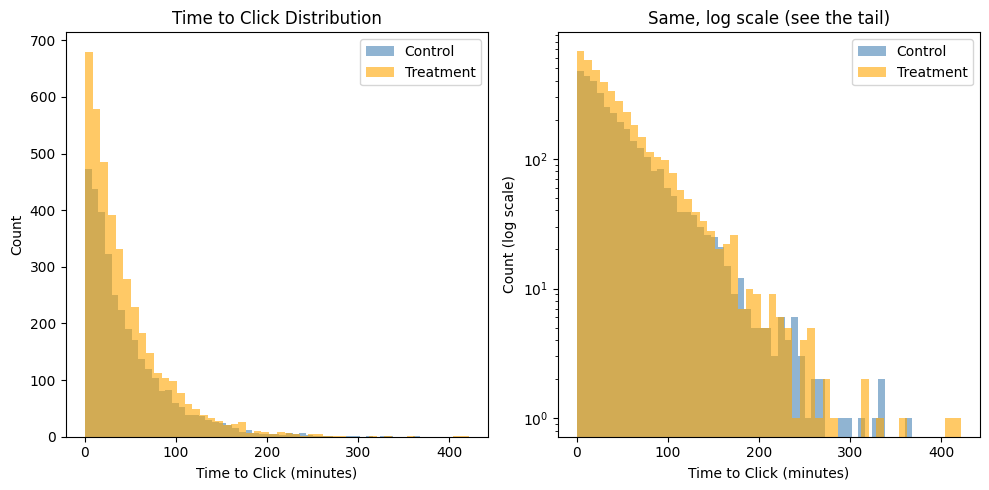

Control:   mean=46.01, median=31.56, std=45.49, n=3413
Treatment: mean=44.88, median=31.24, std=45.04, n=4042


In [50]:
ttc_c = df.loc[(df['arm'] == 'control') & (df['clicked'] == 1), 'time-to-click'].dropna()
ttc_t = df.loc[(df['arm'] == 'treatment') & (df['clicked'] == 1), 'time-to-click'].dropna()

fig, ax = plt.subplots(1,2, figsize=(10,5))
for a in ax:
    a.hist(ttc_c, bins=50, alpha=0.6, label = "Control", color = 'steelblue')
    a.hist(ttc_t, bins=50, alpha=0.6, label = "Treatment", color = 'orange')
    a.set_xlabel('Time to Click (minutes)')
    a.legend()
ax[0].set_ylabel("Count")
ax[0].set_title("Time to Click Distribution")
ax[1].set_yscale("log")
ax[1].set_ylabel('Count (log scale)')

ax[1].set_title("Same, log scale (see the tail)")
plt.tight_layout()
plt.show()

print(f"Control:   mean={ttc_c.mean():.2f}, median={ttc_c.median():.2f}, std={ttc_c.std():.2f}, n={len(ttc_c)}")
print(f"Treatment: mean={ttc_t.mean():.2f}, median={ttc_t.median():.2f}, std={ttc_t.std():.2f}, n={len(ttc_t)}")

In [51]:
# Distribuions are right skewed and look almost identical 

In [52]:
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW
from scipy.stats import mannwhitneyu

In [53]:
cm = CompareMeans(DescrStatsW(ttc_t), DescrStatsW(ttc_c))
t_stat, p_welch, dof = cm.ttest_ind(usevar='unequal')

ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar='unequal')

u_stat, p_mw = mannwhitneyu(ttc_t, ttc_c, alternative='two-sided')

print(f"Welch's t-test: t={t_stat:.3f}, p = {p_welch:.4f}, dof = {dof:.0f}")
print(f"95% CI for diff: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Mann-Whitney U: U={u_stat:.0f}, p = {p_mw:.4f}")

Welch's t-test: t=-1.071, p = 0.2841, dof = 7221
95% CI for diff: [-3.191, 0.936]
Mann-Whitney U: U=6783276, p = 0.2166


## Unsubscribe guardrail

In [54]:
un_c = df.loc[control, 'unsubscribed'].sum()
un_t = df.loc[treatment, 'unsubscribed'].sum()

In [55]:
z_un, p_un = proportions_ztest([un_t, un_c], [n_t, n_c])
ci_un = confint_proportions_2indep(un_t, n_t, un_c, n_c, method='wald')

In [58]:
print(f"Unsubscribe:    C={un_c/n_c:.4f}, T={un_t/n_t:.4f}, "f"diff={un_t/n_t - un_c/n_c:+.4f}, z={z_un:.3f}, p={p_un:.4f}, CI={ci_un}")

Unsubscribe:    C=0.0025, T=0.0028, diff=+0.0003, z=0.865, p=0.3870, CI=(np.float64(-0.00039551689962100004), np.float64(0.0010200048521422146))


## Support Ticket Guardrail

In [59]:
st_c = df.loc[control, 'support ticket'].sum()
st_t = df.loc[treatment, 'support ticket'].sum()

In [60]:
z_st, p_st = proportions_ztest([st_t, st_c], [n_t, n_c])
ci_st = confint_proportions_2indep(st_t, n_t, st_c, n_c, method='wald')
print(f"Support ticket: C={st_c/n_c:.4f}, T={st_t/n_t:.4f}, "
      f"diff={st_t/n_t - st_c/n_c:+.4f}, z={z_st:.3f}, p={p_st:.4f}, CI={ci_st}")

Support ticket: C=0.0123, T=0.0124, diff=+0.0001, z=0.097, p=0.9228, CI=(np.float64(-0.0014535285468919752), np.float64(0.0016047987262171742))
